# Low-ℓ BB — Manual Tile Inspector (g3 source)

Same workflow as `bb_map_inspect.ipynb` but reads from a `.g3.gz` file (SPT3G format).

.

In [1]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
from spt3g import core, maps
from astropy.io import fits
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
sys.path.insert(0, _here)

from Plot import (
    apply_spt_style,
    mask_map,
    show_map_full_field,
    show_map_thumbnail,
)

apply_spt_style()

In [3]:
MASK_DIR = "/sptlocal/user/creichardt/bb2020"
import os
for f in sorted(os.listdir("/sptlocal/user/creichardt/bb2020")):
    print(f)


bigavoidance_puremask_0p5medwt_120arcmin.npz
bigavoidance_puremask_0p5medwt_180arcmin.npz
bk2048_250mJy_30.npz
bk8192_250mJy.npz
bk8192_250mJy_30.npz
bk8192_250mJy_nodisk20.npz
bk8192_250mJy_nodisk30.npz
bk8192_250mJy_nodisk60.npz
border_lines_0p5medwt.npz
bpwf.npz
bwpf.npz
c2_bigavoidance_puremask_0p5medwt_120arcmin.npz
c2_bigavoidance_puremask_0p5medwt_180arcmin.npz
c2_rounded_mask_0p5medwt_120arcmin.npz
c2mask_0p5medwt_120arcmin.npz
c2mask_0p5medwt_238arcmin.npz
c2mask_0p5medwt_60arcmin.npz
c2puremask_0p5medwt_120arcmin.npz
c2puremask_0p5medwt_180arcmin.npz
c2puremask_0p5medwt_240arcmin.npz
c2puremask_0p5medwt_250mJy_120arcmin.npz
c2puremask_0p5medwt_250mJy_180arcmin.npz
c2puremask_0p5medwt_250mJy_240arcmin.npz
circletest_c2puremask_0p5medwt_radius1200_120arcmin.npz
circletest_c2puremask_0p5medwt_radius1200_240arcmin.npz
circletest_c2puremask_0p5medwt_radius1200_480arcmin.npz
circletest_c2puremask_0p5medwt_radius1200_60arcmin.npz
circletest_c2puremask_0p5medwt_radius1800_120arcmin.n

In [5]:
# Choose mask
# Available keys (defined in Paths):
#   puremask_0p5medwt_100mJy_30arcmin.npz
#   puremask_0p5medwt_120arcmin.npz

MASK_FILE = "puremask_0p5medwt_100mJy_30arcmin.npz"

mask_path = os.path.join(MASK_DIR, MASK_FILE)
with np.load(mask_path) as d:
    apod     = d[d.files[0]].astype(float)
    mask_key = d.files[0]

nside_mask = hp.get_nside(apod)


print(f"Mask loaded  : {MASK_FILE}")
print(f"nside        : {nside_mask}")

Mask loaded  : puremask_0p5medwt_100mJy_30arcmin.npz
nside        : 2048


#### Paths

In [14]:
# Stokes selector
# Change to "Q" or "U" and re-run from Load map to inspect a different component.
STOKES_KEY = "T"

_STOKES_FIELD = {"T": 0, "Q": 1, "U": 2}
assert STOKES_KEY in _STOKES_FIELD, f"STOKES_KEY must be T / Q / U, got '{STOKES_KEY}'"

# Frequency selector
# Change to "90GHz" or "150GHz" to switch band.
FREQ = "220GHz"

_FREQ_OPTIONS = {"90GHz", "150GHz", "220GHz"}
assert FREQ in _FREQ_OPTIONS, f"FREQ must be one of {_FREQ_OPTIONS}, got '{FREQ}'"

# g3 data file
G3_FILE = "/sptgrid/user/javva/baseline_bb_coadd_match/coadd_fullauto/full/no_signflip_bundle_000.g3.gz"

# Mask directory
MASK_DIR = "/sptlocal/user/creichardt/bb2020"

# Available masks — refer to this when choosing in Load mask
MASK_FILES = {
    "mask_100_30"  : "puremask_0p5medwt_100mJy_30arcmin.npz",
    "mask_apod_120": "puremask_0p5medwt_120arcmin.npz",
    "mask_apod_180": "puremask_0p5medwt_180arcmin.npz",
    "mask_apod_240": "puremask_0p5medwt_240arcmin.npz",
    "mask_250_120" : "puremask_0p5medwt_250mJy_120arcmin.npz",
    "mask_250_180" : "puremask_0p5medwt_250mJy_180arcmin.npz",
    "mask_250_240" : "puremask_0p5medwt_250mJy_240arcmin.npz",
    "mask_250_30"  : "puremask_0p5medwt_250mJy_30arcmin.npz",
    "mask_250_60"  : "puremask_0p5medwt_250mJy_60arcmin.npz",
    "mask_apod_30" : "puremask_0p5medwt_30arcmin.npz",
    "mask_apod_60" : "puremask_0p5medwt_60arcmin.npz",
}

# Output directory
SAVE_DIR = "/sptlocal/user/vwelke/Code/Map_Operation/lowl_bb_tiles_g3"
os.makedirs(SAVE_DIR, exist_ok=True)

# Display parameters
# nside=2048 → pixel size ~1.7 arcmin, so 2.0 arcmin/px is appropriate here
RESO_ARCMIN = 0.5
PATCH_DEG   = 15.0
PATCH_PIX   = int(PATCH_DEG * 60 / RESO_ARCMIN)
CMAP        = "coolwarm"

print(f"Stokes key  : {STOKES_KEY}")
print(f"Frequency   : {FREQ}")
print(f"Patch size  : {PATCH_DEG}° × {PATCH_DEG}°  =  {PATCH_PIX} × {PATCH_PIX} px")
print(f"Resolution  : {RESO_ARCMIN} arcmin/px")

Stokes key  : T
Frequency   : 220GHz
Patch size  : 15.0° × 15.0°  =  1800 × 1800 px
Resolution  : 0.5 arcmin/px


#### Load map

In [15]:
# Find the frame matching FREQ
target_frame = None
for frame in core.G3File(G3_FILE):
    if frame.type == core.G3FrameType.Map and frame['Id'] == FREQ:
        target_frame = frame
        break

if target_frame is None:
    raise ValueError(f"No Map frame with Id='{FREQ}' found in {G3_FILE}")

# Remove weights using the spt3g function — properly inverts the full
# polarisation weight matrix [QQ, QU; QU, UU], not just the diagonal.
maps.RemoveWeights(target_frame)

# Extract selected Stokes component — now unweighted
stokes_arr = np.array(target_frame[STOKES_KEY])
nside      = target_frame[STOKES_KEY].nside

# Mark unobserved pixels as UNSEEN for healpy compatibility
# (RemoveWeights sets unobserved pixels to 0; obs mask picks those up)
obs_check = np.array(target_frame['Wpol'].TT) > 0
stokes_arr[~obs_check] = hp.UNSEEN

print(f"Loaded     : {STOKES_KEY}  {FREQ}  from  {os.path.basename(G3_FILE)}")
print(f"nside      : {nside}")
print(f"Total pix  : {len(stokes_arr):,}")
print(f"Observed   : {obs_check.sum():,}  ({obs_check.sum()/len(stokes_arr)*100:.2f}% of sky)")

Loaded     : T  220GHz  from  no_signflip_bundle_000.g3.gz
nside      : 2048
Total pix  : 50,331,648
Observed   : 2,290,267  (4.55% of sky)


#### Observed-pixel mask

In [16]:
obs_mask = np.isfinite(stokes_arr) & (stokes_arr != hp.UNSEEN)

obs_pix        = np.where(obs_mask)[0]
theta_c, phi_c = hp.pix2ang(nside, obs_pix)
ra_obs  = np.degrees(phi_c)
ra_obs  = np.where(ra_obs > 180, ra_obs - 360, ra_obs)
dec_obs = 90.0 - np.degrees(theta_c)

ra_min,  ra_max  = ra_obs.min(),  ra_obs.max()
dec_min, dec_max = dec_obs.min(), dec_obs.max()

print(f"Observed pixels  : {obs_mask.sum():,}  ({obs_mask.sum()/len(stokes_arr)*100:.2f}% of sky)")
print(f"RA  range  :  {ra_min:.2f}° → {ra_max:.2f}°   span = {ra_max-ra_min:.2f}°")
print(f"Dec range  : {dec_min:.2f}° → {dec_max:.2f}°   span = {dec_max-dec_min:.2f}°")

Observed pixels  : 2,286,723  (4.54% of sky)
RA  range  :  -56.54° → 53.79°   span = 110.33°
Dec range  : -71.99° → -40.20°   span = 31.79°


#### Tile grid

In [9]:
ra_centres  = np.arange(ra_min  + PATCH_DEG/2, ra_max  + PATCH_DEG/2, PATCH_DEG)
dec_centres = np.arange(dec_min + PATCH_DEG/2, dec_max + PATCH_DEG/2, PATCH_DEG)

n_ra, n_dec = len(ra_centres), len(dec_centres)
print(f"RA  centres  : {n_ra}   [{ra_centres[0]:.1f}° … {ra_centres[-1]:.1f}°]")
print(f"Dec centres  : {n_dec}   [{dec_centres[0]:.1f}° … {dec_centres[-1]:.1f}°]")
print(f"Total patches : {n_ra * n_dec}")
print()
print("RA_IDX  →  RA centre")
for i, r in enumerate(ra_centres):
    print(f"  {i}  →  {r:+.1f}°")
print()
print("DEC_IDX  →  Dec centre")
for j, d in enumerate(dec_centres):
    print(f"  {j}  →  {d:+.1f}°")

RA  centres  : 8   [-49.0° … 56.0°]
Dec centres  : 3   [-64.5° … -34.5°]
Total patches : 24

RA_IDX  →  RA centre
  0  →  -49.0°
  1  →  -34.0°
  2  →  -19.0°
  3  →  -4.0°
  4  →  +11.0°
  5  →  +26.0°
  6  →  +41.0°
  7  →  +56.0°

DEC_IDX  →  Dec centre
  0  →  -64.5°
  1  →  -49.5°
  2  →  -34.5°


In [ ]:
# Run Load map cell first so target_frame exists
stokes_map = target_frame[STOKES_KEY]

print("STOKES_KEY     :", STOKES_KEY)
# Correct attribute
print("map.units  :", stokes_map.units)

# Also check what keys the frame carries (sometimes there's a separate units key)
print("Frame keys :", list(target_frame.keys()))

print()
print("core.G3Units.K  :", core.G3Units.K)
print("core.G3Units.mK :", core.G3Units.mK)
print("core.G3Units.uK :", core.G3Units.uK)

print("the unit is mk")

#### Unmasked patches

Inspect the raw map first — spot bright point sources, decide which mask to use below.

In [39]:
# Choose patch
#   RA_IDX  : 0 … n_ra-1   (west → east)
#   DEC_IDX : 0 … n_dec-1  (south → north)
RA_IDX  = 4
DEC_IDX = 0

ra_c  = ra_centres[RA_IDX]
dec_c = dec_centres[DEC_IDX]
print(f"Patch ({RA_IDX}, {DEC_IDX})  →  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°")

Patch (4, 0)  →  RA +11.0°  Dec -64.5°


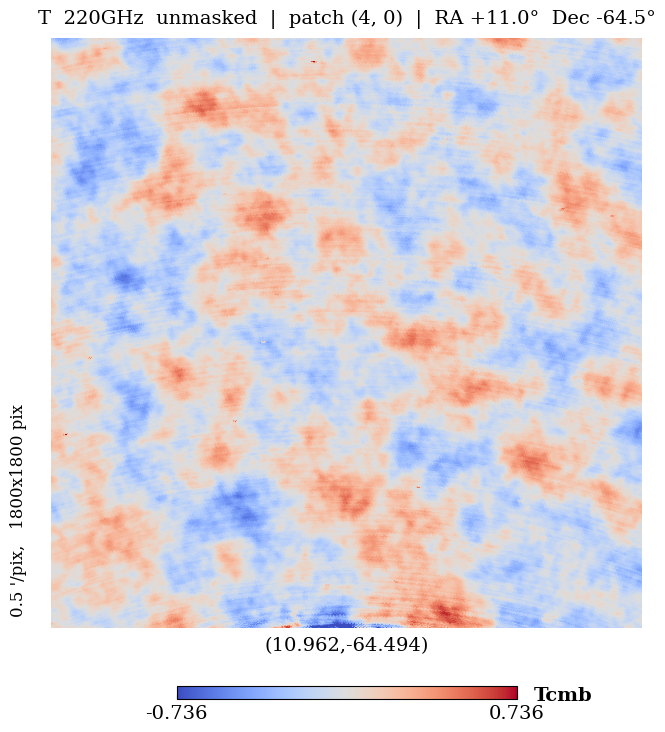

In [40]:
# Plot (unmasked)
rms        = float(np.std(stokes_arr[obs_mask]))
vmin, vmax = -3*rms, 3*rms

show_map_thumbnail(
    stokes_arr,
    vmin=vmin, vmax=vmax,
    title=(
        f"{STOKES_KEY}  {FREQ}  unmasked  |  patch ({RA_IDX}, {DEC_IDX})  "
        f"|  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°"
    ),
    unit="Tcmb", cmap=CMAP,
    rot=(ra_c, dec_c, 0),
    xsize=PATCH_PIX, ysize=PATCH_PIX,
    reso=RESO_ARCMIN,
)
plt.show()

In [43]:
# load the list of sources 
source_path = "/home/creichardt/spt3g_software/sources/mask_lists/"
source_file = os.path.join(source_path, "high_ell_TT_2021_1500d_source_mask_6mJy_plusedges.txt")

with open(source_file) as f:
    print(f.read())

# Derived from spt3g_1500d_source_list_ma_21dec21_v1.txt, and
# spt3g_1500d_winter_edge_source_list_tc_21jul22.txt (for sources
# outside the nominal region) Sources are selected above 6 mJy, and
# radius is set using source_utils.determine_masking_radius with
# threshold=1 mJy.  All sources in the edges are masked with a 5
# arcmin radius.


"index"	"RA(deg)"	"DEC(deg)"	"radius"	"S150(mJy)"
0	1.03127	-43.7525	0.00049451	47.0492398186
1	29.46335	-46.23895	0.0005526876	68.8448893015
2	-30.00315	-47.86492	0.0005526876	63.9436860393
3	14.19209	-44.85019	0.0005526876	64.843385699
4	-7.97615	-41.29597	0.0006108652	75.8471022353
5	-39.05122	-47.22136	0.0006108652	82.0809803757
6	-10.91111	-43.62947	0.0005526876	72.1697910958
7	-2.10337	-42.99225	0.0006108652	83.1909703474
8	-10.22129	-42.1129	0.0005526876	71.4688395837
9	49.49112	-44.23781	0.0006108652	75.8239649972
10	2.29164	-46.21897	0.0006108652	87.1237771956
11	11.56901	-42.12647	0.0006108652	78.0459655879
12	-1.70396	-48.10014	0.000610

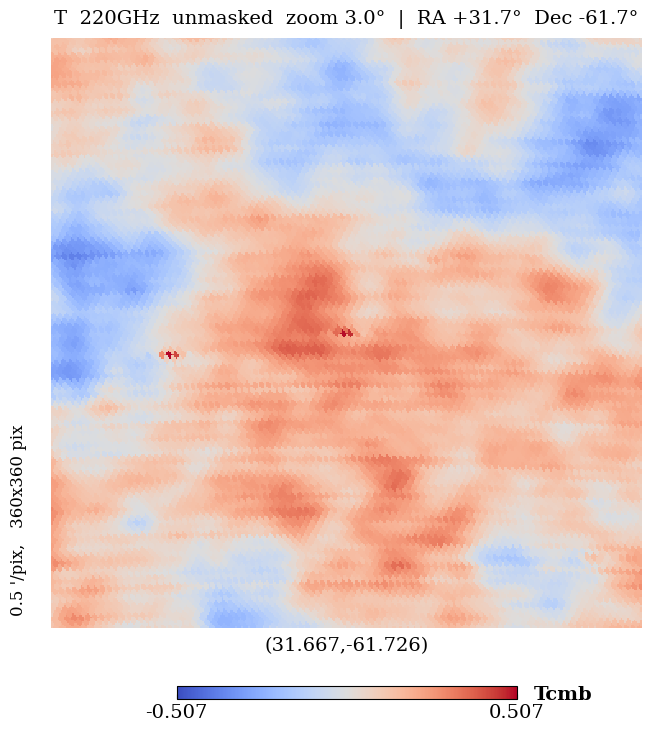

In [45]:
# Zoom in — unmasked
# Change ZOOM_DEG to adjust zoom level
ZOOM_DEG = 3.0
ZOOM_PIX = int(ZOOM_DEG * 60 / RESO_ARCMIN)

RA_source, Dec_source = 31.6671, -61.72633
show_map_thumbnail(
    stokes_arr,
    vmin=vmin, vmax=vmax,
    title=f"{STOKES_KEY}  {FREQ}  unmasked  zoom {ZOOM_DEG}°  |  RA {RA_source:+.1f}°  Dec {Dec_source:+.1f}°",
    unit="Tcmb", cmap=CMAP,
    rot=(RA_source, Dec_source, 0),
    xsize=ZOOM_PIX, ysize=ZOOM_PIX,
    reso=RESO_ARCMIN,
)
plt.show()

In [28]:
# Close
plt.close("all")

#### Load mask

After inspecting the raw patches above, choose a mask from `MASK_FILES` and run this cell.  
The mask is at nside=8192 and will be automatically downgraded to nside=2048 to match the map.

In [47]:
# Choose mask
# Available keys (defined in Paths):
#   mask_250_30   — 250 mJy point-source mask, 30 arcmin apodisation
#   mask_250_60   — 250 mJy point-source mask, 60 arcmin apodisation
#   mask_250_nd30 — 250 mJy, no disk, 30 arcmin
#   mask_250_nd60 — 250 mJy, no disk, 60 arcmin
#   mask_100_30   — 100 mJy point-source mask, 30 arcmin
#   mask_apod_30  — apodisation only, 30 arcmin (no source masking)
#   mask_apod_60  — apodisation only, 60 arcmin (no source masking)
ACTIVE_MASK = "mask_100_30"

mask_path = os.path.join(MASK_DIR, MASK_FILES[ACTIVE_MASK])
with np.load(mask_path) as d:
    apod     = d[d.files[0]].astype(float)
    mask_key = d.files[0]

nside_mask = hp.get_nside(apod)


obs_and_mask = obs_mask & (apod > 0)

# Apply apodisation weight
stokes_masked                 = stokes_arr.copy()
stokes_masked[obs_and_mask]  *= apod[obs_and_mask]
stokes_masked[~obs_and_mask]  = hp.UNSEEN

print(f"Mask loaded  : {ACTIVE_MASK}")
print(f"File         : {MASK_FILES[ACTIVE_MASK]}")
print(f"key='{mask_key}'  |  nside after downgrade={hp.get_nside(apod)}")
print(f"Pixels after mask : {obs_and_mask.sum():,}  (was {obs_mask.sum():,} unmasked)")

Mask loaded  : mask_100_30
File         : puremask_0p5medwt_100mJy_30arcmin.npz
key='mask'  |  nside after downgrade=2048
Pixels after mask : 2,090,018  (was 2,286,723 unmasked)


#### Masked patches

Same `RA_IDX` / `DEC_IDX` as above — easy before/after comparison.

In [41]:
# Choose patch
#   Same RA_IDX / DEC_IDX as above for direct before/after comparison
RA_IDX  = 4
DEC_IDX = 0

ra_c  = ra_centres[RA_IDX]
dec_c = dec_centres[DEC_IDX]
print(f"Patch ({RA_IDX}, {DEC_IDX})  →  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°")

Patch (4, 0)  →  RA +11.0°  Dec -64.5°


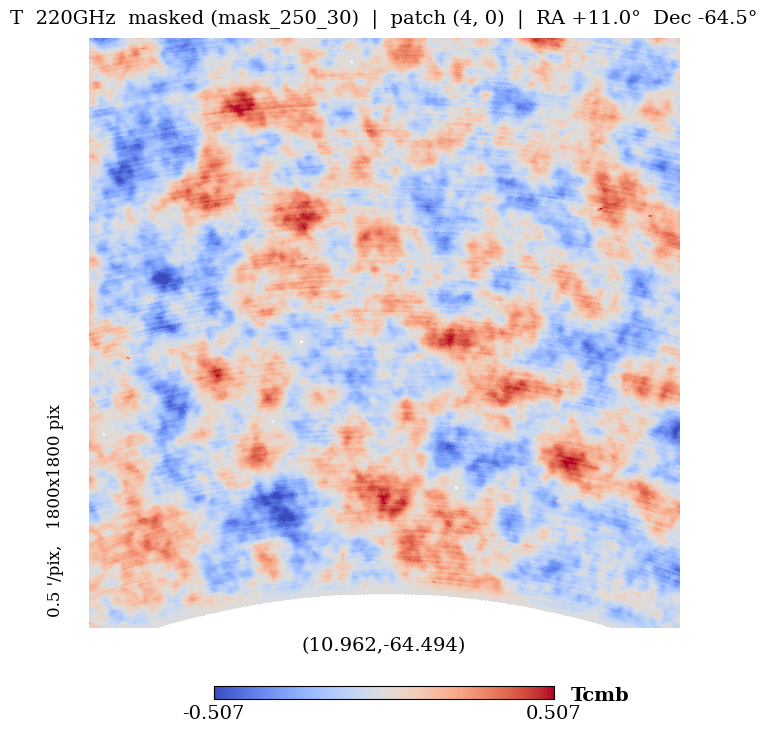

In [42]:
# Plot (masked)
rms        = float(np.std(stokes_masked[obs_and_mask]))
vmin, vmax = -3*rms, 3*rms

show_map_thumbnail(
    stokes_masked,
    vmin=vmin, vmax=vmax,
    title=(
        f"{STOKES_KEY}  {FREQ}  masked ({ACTIVE_MASK})  |  patch ({RA_IDX}, {DEC_IDX})  "
        f"|  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°"
    ),
    unit="Tcmb", cmap=CMAP,
    rot=(ra_c, dec_c, 0),
    xsize=PATCH_PIX, ysize=PATCH_PIX,
    reso=RESO_ARCMIN,
)
plt.show()

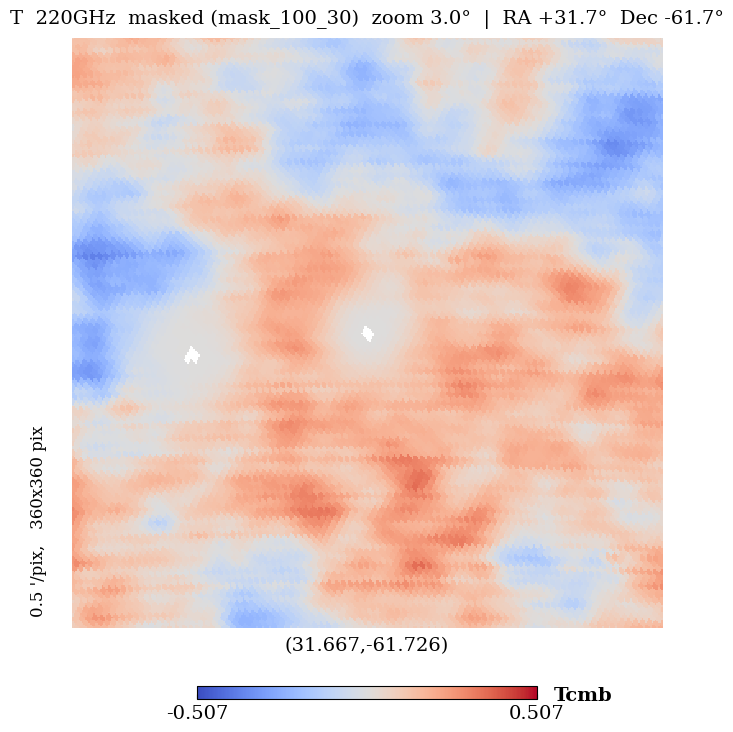

In [48]:
# Zoom in — masked
# Change ZOOM_DEG to adjust zoom level
ZOOM_DEG = 3.0
ZOOM_PIX = int(ZOOM_DEG * 60 / RESO_ARCMIN)

show_map_thumbnail(
    stokes_masked,
    vmin=vmin, vmax=vmax,
    title=f"{STOKES_KEY}  {FREQ}  masked ({ACTIVE_MASK})  zoom {ZOOM_DEG}°  |  RA {RA_source:+.1f}°  Dec {Dec_source:+.1f}°",
    unit="Tcmb", cmap=CMAP,
    rot=(RA_source, Dec_source, 0),
    xsize=ZOOM_PIX, ysize=ZOOM_PIX,
    reso=RESO_ARCMIN,
)
plt.show()

In [33]:
# Close
plt.close("all")

#### Power spectrum (draft)

> Draft only — no beam correction, no mode-coupling / purification.

In [ ]:
# Noise PSD from sign-flip maps
# Requires Load mask to have been run first — uses apod, obs_and_mask, FREQ.

# Add sign-flip g3 file paths here
SIGNFLIP_FILES = [
    # "/sptgrid/.../signflip_bundle_000.g3.gz",
    # "/sptgrid/.../signflip_bundle_001.g3.gz",
]

LMAX = 600

if len(SIGNFLIP_FILES) == 0:
    print("No sign-flip files listed — add paths to SIGNFLIP_FILES above.")
else:
    cl_BB_sum = np.zeros(LMAX + 1)
    N = len(SIGNFLIP_FILES)

    for i, fpath in enumerate(SIGNFLIP_FILES):
        # Find the frame matching FREQ
        _sf_frame = None
        for frame in core.G3File(fpath):
            if frame.type == core.G3FrameType.Map and frame['Id'] == FREQ:
                _sf_frame = frame
                break

        if _sf_frame is None:
            print(f"  [{i+1}/{N}]  WARNING: no '{FREQ}' frame in {os.path.basename(fpath)}, skipping")
            continue

        # Deweight using spt3g
        maps.RemoveWeights(_sf_frame)

        Q_sf = np.array(_sf_frame['Q'])
        U_sf = np.array(_sf_frame['U'])

        # Apply apodisation mask
        Q_sf[obs_and_mask]  *= apod[obs_and_mask]
        Q_sf[~obs_and_mask]  = 0.0
        U_sf[obs_and_mask]  *= apod[obs_and_mask]
        U_sf[~obs_and_mask]  = 0.0

        # SHT → pseudo-C_ell, accumulate BB
        T_zeros = np.zeros(len(Q_sf))
        cls      = hp.anafast([T_zeros, Q_sf, U_sf], lmax=LMAX)
        cl_BB_sum += cls[2]

        del _sf_frame, Q_sf, U_sf, T_zeros, cls   # free memory before next file
        print(f"  [{i+1}/{N}]  {os.path.basename(fpath)}")

    # Average over all sign-flip maps → noise pseudo-C_ell
    cl_BB_noise = cl_BB_sum / N
    ell = np.arange(LMAX + 1)
    print(f"\nDone. Averaged over {N} sign-flip maps.")

In [ ]:
# Plot noise BB pseudo-D_ell
if len(SIGNFLIP_FILES) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl_BB_noise[2:] / (2 * np.pi),
            label=f"BB noise  (N={N} sign-flip maps)")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$D_\ell^{BB}$  [$\mu{\rm K}^2$]")
    ax.set_title(
        f"BB noise pseudo-$C_\\ell$  |  {FREQ}  |  mask: {ACTIVE_MASK}\n"
        f"(draft — no beam/mode-coupling correction)"
    )
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

**Open question:** what to store alongside `N_l`?
- Just the `ell` array + `N_l` (noise Cl) as a pair?
- Or also the signal `C_l` from the coadd map, so both can be plotted together?
- Or the raw `a_lm` coefficients from each sign-flip map for later use?

In [ ]:
# Save C_ell to FITS — uncomment when ready
# out_cl = os.path.join(SAVE_DIR, f"cl_BB_{FREQ}_{ACTIVE_MASK}.fits")
# hp.write_cl(out_cl, cls, overwrite=True)
# print(f"C_ell saved → {out_cl}")